# EDA 15.5: Reviews, Returns, and Revenue Analysis

This notebook analyzes the relationship among reviews, ratings, returns, and Revenue, with emphasis on whether low ratings are associated with higher returns, whether category rating deterioration is followed by Revenue decline, and whether review volume can act as a demand signal.

## 1. Setup and File Discovery

Locate the required CSV files under the current working directory. Missing files produce warnings and the notebook continues where possible.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 240)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['reviews.csv', 'returns.csv', 'products.csv', 'orders.csv', 'order_items.csv', 'sales.csv']
REQUIRED = set(FILES)

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'required': name in REQUIRED, 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None and name in REQUIRED:
        warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,reviews.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\re...
1,returns.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\re...
2,products.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\pr...
3,orders.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
4,order_items.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
5,sales.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...


## 2. Load Reviews, Returns, Products, Orders, Order Items, and Sales

Load all inputs safely with pandas and display schema summaries.

In [2]:
def load_csv_safe(path):
    if path is None:
        return None
    try:
        return pd.read_csv(path, low_memory=False)
    except Exception as exc:
        warnings.warn(f'Failed to load {path}: {exc}')
        return None

data = {name.replace('.csv', ''): load_csv_safe(path) for name, path in selected_paths.items()}
reviews = data.get('reviews')
returns = data.get('returns')
products = data.get('products')
orders = data.get('orders')
order_items = data.get('order_items')
sales = data.get('sales')

schema_rows = []
for name, df in data.items():
    schema_rows.append({
        'dataset': name,
        'loaded': df is not None,
        'rows': None if df is None else len(df),
        'columns': None if df is None else ', '.join(map(str, df.columns[:20]))
    })
display(pd.DataFrame(schema_rows))

,dataset,loaded,rows,columns
0,reviews,True,113551,"review_id, order_id, product_id, customer_id, ..."
1,returns,True,39939,"return_id, order_id, product_id, return_date, ..."
2,products,True,2412,"product_id, product_name, category, segment, s..."
3,orders,True,646945,"order_id, order_date, customer_id, zip, order_..."
4,order_items,True,714669,"order_id, product_id, quantity, unit_price, di..."
5,sales,True,3833,"Date, Revenue, COGS"


## 3. Identify Review, Return, Product, Category, Revenue, and Date Columns

Use tolerant matching for likely naming variations. Revenue uses `sales.csv` for aggregate daily totals and `order_items` for product/category-level Revenue.

In [3]:
def normalized_map(columns):
    return {normalize_name(c): c for c in columns}

def find_column(columns, candidates, contains=False):
    nmap = normalized_map(columns)
    normalized_candidates = [normalize_name(c) for c in candidates]
    for cand in normalized_candidates:
        if cand in nmap:
            return nmap[cand]
    if contains:
        for cand in normalized_candidates:
            for ncol, raw in nmap.items():
                if cand in ncol:
                    return raw
    return None

review_cols = {}
if reviews is not None:
    review_cols = {
        'review_id': find_column(reviews.columns, ['review_id', 'id'], contains=True),
        'order_id': find_column(reviews.columns, ['order_id']),
        'product_id': find_column(reviews.columns, ['product_id']),
        'customer_id': find_column(reviews.columns, ['customer_id'], contains=True),
        'review_date': find_column(reviews.columns, ['review_date', 'date'], contains=True),
        'rating': find_column(reviews.columns, ['rating', 'score', 'stars'], contains=True),
    }

return_cols = {}
if returns is not None:
    return_cols = {
        'return_id': find_column(returns.columns, ['return_id', 'id'], contains=True),
        'order_id': find_column(returns.columns, ['order_id']),
        'product_id': find_column(returns.columns, ['product_id']),
        'return_date': find_column(returns.columns, ['return_date', 'date'], contains=True),
        'return_reason': find_column(returns.columns, ['return_reason', 'reason'], contains=True),
        'return_quantity': find_column(returns.columns, ['return_quantity', 'quantity_returned', 'qty'], contains=True),
        'refund_amount': find_column(returns.columns, ['refund_amount', 'refund', 'refund_value'], contains=True),
    }

product_cols = {}
if products is not None:
    product_cols = {
        'product_id': find_column(products.columns, ['product_id']),
        'product_name': find_column(products.columns, ['product_name', 'name', 'title'], contains=True),
        'category': find_column(products.columns, ['category']),
        'size': find_column(products.columns, ['size']),
        'segment': find_column(products.columns, ['segment']),
    }

orders_cols = {}
if orders is not None:
    orders_cols = {
        'order_id': find_column(orders.columns, ['order_id']),
        'order_date': find_column(orders.columns, ['order_date', 'date'], contains=True),
        'customer_id': find_column(orders.columns, ['customer_id'], contains=True),
        'order_status': find_column(orders.columns, ['order_status', 'status'], contains=True),
    }

item_cols = {}
if order_items is not None:
    item_cols = {
        'order_id': find_column(order_items.columns, ['order_id']),
        'product_id': find_column(order_items.columns, ['product_id']),
        'quantity': find_column(order_items.columns, ['quantity', 'qty', 'units'], contains=True),
        'unit_price': find_column(order_items.columns, ['unit_price', 'price', 'selling_price'], contains=True),
        'discount_amount': find_column(order_items.columns, ['discount_amount', 'discount'], contains=True),
        'item_revenue': find_column(order_items.columns, ['item_total', 'line_total', 'revenue', 'sales_amount', 'net_sales'], contains=True),
    }

sales_cols = {}
if sales is not None:
    sales_cols = {
        'date': find_column(sales.columns, ['date', 'sales_date', 'order_date'], contains=True),
        'revenue': find_column(sales.columns, ['revenue', 'sales_amount', 'total_revenue'], contains=True),
    }

identified = pd.DataFrame({
    'reviews': pd.Series(review_cols),
    'returns': pd.Series(return_cols),
    'products': pd.Series(product_cols),
    'orders': pd.Series(orders_cols),
    'order_items': pd.Series(item_cols),
    'sales': pd.Series(sales_cols),
})
display(identified)

,reviews,returns,products,orders,order_items,sales
category,NaN,NaN,category,NaN,NaN,NaN
customer_id,customer_id,NaN,NaN,customer_id,NaN,NaN
date,NaN,NaN,NaN,NaN,NaN,Date
discount_amount,NaN,NaN,NaN,NaN,discount_amount,NaN
item_revenue,NaN,NaN,NaN,NaN,None,NaN
order_date,NaN,NaN,NaN,order_date,NaN,NaN
order_id,order_id,order_id,NaN,order_id,order_id,NaN
order_status,NaN,NaN,NaN,order_status,NaN,NaN
product_id,product_id,product_id,product_id,NaN,product_id,NaN
product_name,NaN,NaN,product_name,NaN,NaN,NaN


## 4. Reviews Data Quality Checks

Standardize review dates and ratings, then inspect missingness, invalid ratings, duplicates, and overall rating shape.

In [4]:
rr_warnings = []
reviews_clean = None

if reviews is not None:
    reviews_clean = reviews.copy()
    reviews_clean['review_id_std'] = reviews_clean[review_cols['review_id']] if review_cols.get('review_id') else pd.NA
    reviews_clean['order_id_std'] = reviews_clean[review_cols['order_id']] if review_cols.get('order_id') else pd.NA
    reviews_clean['product_id_std'] = reviews_clean[review_cols['product_id']] if review_cols.get('product_id') else pd.NA
    reviews_clean['customer_id_std'] = reviews_clean[review_cols['customer_id']] if review_cols.get('customer_id') else pd.NA
    reviews_clean['review_date_std'] = pd.to_datetime(reviews_clean[review_cols['review_date']], errors='coerce') if review_cols.get('review_date') else pd.NaT
    reviews_clean['rating_std'] = pd.to_numeric(reviews_clean[review_cols['rating']], errors='coerce') if review_cols.get('rating') else np.nan
    reviews_clean['low_rating_flag'] = reviews_clean['rating_std'].le(2)
    reviews_clean['high_rating_flag'] = reviews_clean['rating_std'].ge(4)

    dup_cols = ['review_id_std'] if reviews_clean['review_id_std'].notna().any() else ['order_id_std', 'product_id_std', 'review_date_std']
    invalid_rating = reviews_clean['rating_std'].notna() & ~reviews_clean['rating_std'].between(1, 5)
    quality = pd.DataFrame([{
        'review_rows': len(reviews_clean),
        'review_date_start': reviews_clean['review_date_std'].min(),
        'review_date_end': reviews_clean['review_date_std'].max(),
        'missing_review_dates': int(reviews_clean['review_date_std'].isna().sum()),
        'missing_ratings': int(reviews_clean['rating_std'].isna().sum()),
        'invalid_ratings': int(invalid_rating.sum()),
        'missing_product_ids': int(reviews_clean['product_id_std'].isna().sum()),
        'missing_order_ids': int(reviews_clean['order_id_std'].isna().sum()),
        'duplicate_review_records': int(reviews_clean.duplicated(subset=dup_cols).sum()),
    }])
    display(quality)
    display(reviews_clean['rating_std'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame('rating_summary'))
    display(reviews_clean['rating_std'].value_counts(dropna=False).sort_index().rename_axis('rating').reset_index(name='count'))
else:
    warnings.warn('reviews.csv unavailable.')

,review_rows,review_date_start,review_date_end,missing_review_dates,missing_ratings,invalid_ratings,missing_product_ids,missing_order_ids,duplicate_review_records
0,113551,2012-07-10,2022-12-31,0,0,0,0,0,0


,rating_summary
count,"113,551.0000"
mean,3.9360
std,1.1499
min,1.0000
5%,1.0000
25%,3.0000
50%,4.0000
75%,5.0000
95%,5.0000
max,5.0000


,rating,count
0,1,5772
1,2,9095
2,3,17016
3,4,36412
4,5,45256


## 5. Returns Data Quality Checks

Standardize return dates, quantities, refunds, and reasons, then inspect missingness and duplicate risks.

In [5]:
returns_clean = None

def standardize_reason(value):
    if pd.isna(value):
        return np.nan
    raw = str(value).strip().lower().replace('-', '_').replace(' ', '_')
    replacements = {
        'size_issue': 'wrong_size',
        'too_small': 'wrong_size',
        'too_large': 'wrong_size',
        'fit_issue': 'wrong_size',
        'changedmind': 'changed_mind',
        'no_longer_needed': 'changed_mind',
        'buyer_remorse': 'changed_mind',
        'did_not_want': 'changed_mind',
        'damaged': 'defective',
        'faulty': 'defective',
    }
    return replacements.get(raw, raw)

if returns is not None:
    returns_clean = returns.copy()
    returns_clean['return_id_std'] = returns_clean[return_cols['return_id']] if return_cols.get('return_id') else pd.NA
    returns_clean['order_id_std'] = returns_clean[return_cols['order_id']] if return_cols.get('order_id') else pd.NA
    returns_clean['product_id_std'] = returns_clean[return_cols['product_id']] if return_cols.get('product_id') else pd.NA
    returns_clean['return_date_std'] = pd.to_datetime(returns_clean[return_cols['return_date']], errors='coerce') if return_cols.get('return_date') else pd.NaT
    returns_clean['return_reason_std'] = returns_clean[return_cols['return_reason']].map(standardize_reason) if return_cols.get('return_reason') else np.nan
    returns_clean['return_quantity_std'] = pd.to_numeric(returns_clean[return_cols['return_quantity']], errors='coerce') if return_cols.get('return_quantity') else np.nan
    returns_clean['refund_amount_std'] = pd.to_numeric(returns_clean[return_cols['refund_amount']], errors='coerce') if return_cols.get('refund_amount') else np.nan

    dup_cols = ['return_id_std'] if returns_clean['return_id_std'].notna().any() else ['order_id_std', 'product_id_std', 'return_date_std']
    quality = pd.DataFrame([{
        'return_rows': len(returns_clean),
        'return_date_start': returns_clean['return_date_std'].min(),
        'return_date_end': returns_clean['return_date_std'].max(),
        'missing_return_dates': int(returns_clean['return_date_std'].isna().sum()),
        'missing_product_ids': int(returns_clean['product_id_std'].isna().sum()),
        'missing_order_ids': int(returns_clean['order_id_std'].isna().sum()),
        'missing_return_quantities': int(returns_clean['return_quantity_std'].isna().sum()),
        'missing_refund_amounts': int(returns_clean['refund_amount_std'].isna().sum()),
        'duplicate_return_records': int(returns_clean.duplicated(subset=dup_cols).sum()),
    }])
    display(quality)
else:
    warnings.warn('returns.csv unavailable.')

,return_rows,return_date_start,return_date_end,missing_return_dates,missing_product_ids,missing_order_ids,missing_return_quantities,missing_refund_amounts,duplicate_return_records
0,39939,2012-07-11,2022-12-31,0,0,0,0,0,0


## 6. Build Product and Category Enriched Datasets

Join reviews and returns to products, and build an item-level Revenue dataset from `order_items + orders + products`.

In [6]:
review_enriched = pd.DataFrame()
return_enriched = pd.DataFrame()
sales_items = pd.DataFrame()

if products is not None and product_cols.get('product_id'):
    prod_cols = [product_cols['product_id']]
    rename_map = {product_cols['product_id']: 'product_id_std'}
    for key in ['product_name', 'category', 'size', 'segment']:
        if product_cols.get(key):
            prod_cols.append(product_cols[key])
            rename_map[product_cols[key]] = key
    prod = products[prod_cols].rename(columns=rename_map)
else:
    prod = pd.DataFrame(columns=['product_id_std'])

if reviews_clean is not None:
    review_enriched = reviews_clean.merge(prod, on='product_id_std', how='left', indicator='product_merge')
    display(pd.DataFrame([{
        'reviews_matched_to_products': int((review_enriched['product_merge'] == 'both').sum()),
        'reviews_unmatched_to_products': int((review_enriched['product_merge'] == 'left_only').sum()),
    }]))

if returns_clean is not None:
    return_enriched = returns_clean.merge(prod, on='product_id_std', how='left', indicator='product_merge')
    display(pd.DataFrame([{
        'returns_matched_to_products': int((return_enriched['product_merge'] == 'both').sum()),
        'returns_unmatched_to_products': int((return_enriched['product_merge'] == 'left_only').sum()),
    }]))

if order_items is not None and orders is not None and item_cols.get('order_id') and orders_cols.get('order_id'):
    oi = order_items.copy()
    oi['order_id_std'] = oi[item_cols['order_id']]
    oi['product_id_std'] = oi[item_cols['product_id']] if item_cols.get('product_id') else pd.NA
    oi['quantity_std'] = pd.to_numeric(oi[item_cols['quantity']], errors='coerce') if item_cols.get('quantity') else np.nan
    oi['unit_price_std'] = pd.to_numeric(oi[item_cols['unit_price']], errors='coerce') if item_cols.get('unit_price') else np.nan
    oi['discount_amount_std'] = pd.to_numeric(oi[item_cols['discount_amount']], errors='coerce').fillna(0) if item_cols.get('discount_amount') else 0
    if item_cols.get('item_revenue'):
        oi['item_revenue_std'] = pd.to_numeric(oi[item_cols['item_revenue']], errors='coerce')
    else:
        oi['item_revenue_std'] = oi['quantity_std'] * oi['unit_price_std']

    ord_df = orders[[orders_cols['order_id'], orders_cols['order_date'], orders_cols['order_status']]].rename(columns={
        orders_cols['order_id']: 'order_id_std',
        orders_cols['order_date']: 'order_date_raw',
        orders_cols['order_status']: 'order_status_raw',
    })
    ord_df['order_date_std'] = pd.to_datetime(ord_df['order_date_raw'], errors='coerce')
    ord_df['order_status_std'] = ord_df['order_status_raw'].astype(str).str.strip().str.lower()

    sales_items = oi.merge(ord_df[['order_id_std', 'order_date_std', 'order_status_std']], on='order_id_std', how='left', indicator='orders_merge')
    sales_items = sales_items.merge(prod, on='product_id_std', how='left', indicator='products_merge')
    display(pd.DataFrame([{
        'order_items_matched_to_orders': int((sales_items['orders_merge'] == 'both').sum()),
        'order_items_matched_to_products': int((sales_items['products_merge'] == 'both').sum()),
    }]))
else:
    print('Item-level Revenue dataset could not be fully built.')

,reviews_matched_to_products,reviews_unmatched_to_products
0,113551,0


,returns_matched_to_products,returns_unmatched_to_products
0,39939,0


,order_items_matched_to_orders,order_items_matched_to_products
0,714669,714669


## 7. Prepare Revenue and Sales Volume

Use `sales.csv` for aggregate daily Revenue and `order_items` for category-month Revenue, order count, and quantity sold.

In [7]:
daily_revenue = pd.DataFrame()
category_month = pd.DataFrame()

if sales is not None and sales_cols.get('date') and sales_cols.get('revenue'):
    sc = sales.copy()
    sc['date_std'] = pd.to_datetime(sc[sales_cols['date']], errors='coerce')
    sc['Revenue_std'] = pd.to_numeric(sc[sales_cols['revenue']], errors='coerce')
    daily_revenue = sc.groupby('date_std').agg(Revenue=('Revenue_std', 'sum')).reset_index().rename(columns={'date_std': 'date'})
    display(daily_revenue.head(10))

if not sales_items.empty and sales_items['order_date_std'].notna().any():
    sales_items['month'] = sales_items['order_date_std'].dt.to_period('M').dt.to_timestamp()
    category_month = sales_items.groupby(['month', 'category']).agg(
        Revenue=('item_revenue_std', 'sum'),
        order_count=('order_id_std', 'nunique'),
        quantity_sold=('quantity_std', 'sum'),
    ).reset_index()
    display(category_month.head(15))
else:
    print('Category-level Revenue is unavailable because item-level order joins are incomplete.')

,date,Revenue
0,2012-07-04,"5,123,547.9400"
1,2012-07-05,"2,751,773.4500"
2,2012-07-06,"3,054,029.4200"
3,2012-07-07,"2,667,930.9400"
4,2012-07-08,"2,360,851.9000"
5,2012-07-09,"3,548,386.4600"
6,2012-07-10,"5,234,938.6200"
7,2012-07-11,"5,582,884.7800"
8,2012-07-12,"5,734,632.0200"
9,2012-07-13,"5,309,511.7100"


,month,category,Revenue,order_count,quantity_sold
0,2012-07-01,Casual,"2,383,588.6900",135,627
1,2012-07-01,GenZ,"2,251,165.2900",314,1437
2,2012-07-01,Outdoor,"17,723,691.1100",1584,9471
3,2012-07-01,Streetwear,"108,048,328.4200",3283,14849
4,2012-08-01,Casual,"2,606,049.5700",129,569
5,2012-08-01,GenZ,"2,529,211.7300",342,1531
6,2012-08-01,Outdoor,"26,199,339.4800",2223,12939
7,2012-08-01,Streetwear,"127,754,639.5300",3784,17204
8,2012-09-01,Casual,"1,833,063.9200",106,472
9,2012-09-01,GenZ,"1,671,792.0700",235,1042


## 8. Low Rating vs Return Rate

Compare low-rating pressure with return pressure at product and category level.

,product_id_std,review_count,avg_rating,low_rating_ratio,category,ordered_quantity,gross_revenue,order_count,return_count,returned_quantity,refund_amount,return_rate,refund_to_revenue_ratio
1367,2340,1,2.0000,1.0000,Streetwear,13,"72,421.9900",2,1.0000,4.0000,"21,345.0600",0.3077,0.2947
782,1298,1,2.0000,1.0000,Casual,80,"356,156.7100",21,4.0000,12.0000,"51,225.1200",0.1500,0.1438
155,323,1,1.0000,1.0000,Streetwear,7,"59,285.8600",2,1.0000,1.0000,"7,883.1300",0.1429,0.1330
1001,1688,1,2.0000,1.0000,Streetwear,57,"104,719.9000",11,1.0000,7.0000,"12,952.3300",0.1228,0.1237
752,1240,1,1.0000,1.0000,Casual,33,"178,227.5800",10,2.0000,4.0000,"22,477.5000",0.1212,0.1261
1062,1796,3,1.6667,1.0000,Streetwear,71,"601,504.1600",15,2.0000,7.0000,"58,250.1200",0.0986,0.0968
786,1304,1,1.0000,1.0000,Casual,139,"645,597.1300",31,2.0000,7.0000,"33,534.5400",0.0504,0.0519
862,1423,1,2.0000,1.0000,Outdoor,62,"249,432.4100",14,1.0000,1.0000,"3,252.8200",0.0161,0.0130
24,52,1,1.0000,1.0000,Outdoor,15,"59,636.0400",3,0.0000,0.0000,0.0000,0.0000,0.0000
81,196,1,2.0000,1.0000,Streetwear,102,"979,058.1300",24,0.0000,0.0000,0.0000,0.0000,0.0000


,category,review_count,avg_rating,low_rating_ratio,return_count,returned_quantity,refund_amount,Revenue,ordered_quantity,order_count,return_rate,refund_to_revenue_ratio
0,Casual,3790,3.9232,0.1372,1294,3499,"14,027,094.3700","460,648,383.3500",107469,23600,0.0326,0.0305
1,GenZ,5792,3.9228,0.1321,2126,5869,"11,145,648.1700","343,599,095.3600",166848,37054,0.0352,0.0324
2,Outdoor,41265,3.9339,0.1311,14720,40417,"78,717,514.8800","2,494,882,754.2000",1170000,200454,0.0345,0.0316
3,Streetwear,62704,3.9394,0.1303,21799,59801,"406,708,249.1300","13,131,346,352.6200",1768826,389543,0.0338,0.0310


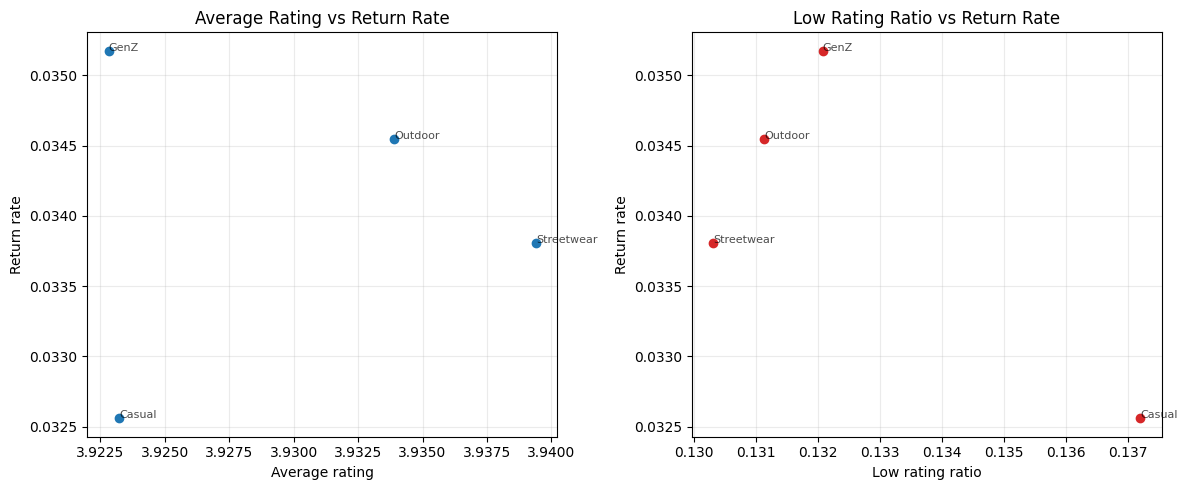

In [8]:
product_review = pd.DataFrame()
product_return = pd.DataFrame()
category_risk = pd.DataFrame()

if not review_enriched.empty:
    product_review = review_enriched.groupby('product_id_std').agg(
        review_count=('rating_std', 'size'),
        avg_rating=('rating_std', 'mean'),
        low_rating_ratio=('low_rating_flag', 'mean'),
        category=('category', 'first'),
    ).reset_index()

if not sales_items.empty:
    product_sales = sales_items.groupby('product_id_std').agg(
        ordered_quantity=('quantity_std', 'sum'),
        gross_revenue=('item_revenue_std', 'sum'),
        order_count=('order_id_std', 'nunique'),
        category=('category', 'first'),
    ).reset_index()
else:
    product_sales = pd.DataFrame()

if not return_enriched.empty:
    product_return = return_enriched.groupby('product_id_std').agg(
        return_count=('product_id_std', 'size'),
        returned_quantity=('return_quantity_std', 'sum'),
        refund_amount=('refund_amount_std', 'sum'),
        category=('category', 'first'),
    ).reset_index()
else:
    product_return = pd.DataFrame()

if not product_review.empty and not product_sales.empty:
    product_risk = product_review.merge(product_sales, on=['product_id_std', 'category'], how='left')
    if not product_return.empty:
        product_risk = product_risk.merge(product_return[['product_id_std', 'return_count', 'returned_quantity', 'refund_amount']], on='product_id_std', how='left')
    product_risk['return_count'] = product_risk['return_count'].fillna(0)
    product_risk['returned_quantity'] = product_risk['returned_quantity'].fillna(0)
    product_risk['refund_amount'] = product_risk['refund_amount'].fillna(0)
    product_risk['return_rate'] = np.where(product_risk['ordered_quantity'] > 0, product_risk['returned_quantity'] / product_risk['ordered_quantity'], np.nan)
    product_risk['refund_to_revenue_ratio'] = np.where(product_risk['gross_revenue'] > 0, product_risk['refund_amount'] / product_risk['gross_revenue'], np.nan)
    display(product_risk.sort_values(['low_rating_ratio', 'return_rate'], ascending=False).head(20))

    cat_reviews = review_enriched.groupby('category').agg(
        review_count=('rating_std', 'size'),
        avg_rating=('rating_std', 'mean'),
        low_rating_ratio=('low_rating_flag', 'mean'),
    ).reset_index()
    cat_returns = return_enriched.groupby('category').agg(
        return_count=('category', 'size'),
        returned_quantity=('return_quantity_std', 'sum'),
        refund_amount=('refund_amount_std', 'sum'),
    ).reset_index() if not return_enriched.empty else pd.DataFrame()
    cat_sales = sales_items.groupby('category').agg(
        Revenue=('item_revenue_std', 'sum'),
        ordered_quantity=('quantity_std', 'sum'),
        order_count=('order_id_std', 'nunique'),
    ).reset_index() if not sales_items.empty else pd.DataFrame()
    category_risk = cat_reviews.merge(cat_returns, on='category', how='left').merge(cat_sales, on='category', how='left')
    category_risk['returned_quantity'] = category_risk['returned_quantity'].fillna(0)
    category_risk['refund_amount'] = category_risk['refund_amount'].fillna(0)
    category_risk['return_rate'] = np.where(category_risk['ordered_quantity'] > 0, category_risk['returned_quantity'] / category_risk['ordered_quantity'], np.nan)
    category_risk['refund_to_revenue_ratio'] = np.where(category_risk['Revenue'] > 0, category_risk['refund_amount'] / category_risk['Revenue'], np.nan)
    display(category_risk)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    tmp = category_risk.dropna(subset=['avg_rating', 'return_rate'])
    axes[0].scatter(tmp['avg_rating'], tmp['return_rate'], color='tab:blue')
    for row in tmp.itertuples():
        axes[0].annotate(row.category, (row.avg_rating, row.return_rate), fontsize=8, alpha=0.7)
    axes[0].set_title('Average Rating vs Return Rate')
    axes[0].set_xlabel('Average rating')
    axes[0].set_ylabel('Return rate')

    tmp2 = category_risk.dropna(subset=['low_rating_ratio', 'return_rate'])
    axes[1].scatter(tmp2['low_rating_ratio'], tmp2['return_rate'], color='tab:red')
    for row in tmp2.itertuples():
        axes[1].annotate(row.category, (row.low_rating_ratio, row.return_rate), fontsize=8, alpha=0.7)
    axes[1].set_title('Low Rating Ratio vs Return Rate')
    axes[1].set_xlabel('Low rating ratio')
    axes[1].set_ylabel('Return rate')
    plt.tight_layout()
    plt.show()
else:
    print('Low rating vs return-rate analysis is limited because product or category joins are incomplete.')

## 9. Category Rating and Future Revenue

Compare lagged category rating metrics with future category Revenue at monthly level.

In [9]:
category_month_reviews = pd.DataFrame()
category_future = pd.DataFrame()

if not review_enriched.empty and not category_month.empty and review_enriched['review_date_std'].notna().any():
    review_enriched['month'] = review_enriched['review_date_std'].dt.to_period('M').dt.to_timestamp()
    category_month_reviews = review_enriched.groupby(['month', 'category']).agg(
        avg_rating=('rating_std', 'mean'),
        review_count=('rating_std', 'size'),
        low_rating_ratio=('low_rating_flag', 'mean'),
    ).reset_index()

    category_future = category_month_reviews.merge(category_month, on=['month', 'category'], how='left')
    category_future = category_future.sort_values(['category', 'month'])
    category_future['avg_rating_lag_1m'] = category_future.groupby('category')['avg_rating'].shift(1)
    category_future['review_count_lag_1m'] = category_future.groupby('category')['review_count'].shift(1)
    category_future['low_rating_ratio_lag_1m'] = category_future.groupby('category')['low_rating_ratio'].shift(1)
    category_future['avg_rating_lag_3m'] = category_future.groupby('category')['avg_rating'].shift(3)
    category_future['future_Revenue_1m'] = category_future.groupby('category')['Revenue'].shift(-1)
    category_future['future_Revenue_3m'] = category_future.groupby('category')['Revenue'].shift(-3)
    display(category_future.head(20))

    lag_corr = pd.DataFrame([
        {'feature': 'avg_rating_lag_1m', 'target': 'future_Revenue_1m', 'correlation': category_future['avg_rating_lag_1m'].corr(category_future['future_Revenue_1m'])},
        {'feature': 'low_rating_ratio_lag_1m', 'target': 'future_Revenue_1m', 'correlation': category_future['low_rating_ratio_lag_1m'].corr(category_future['future_Revenue_1m'])},
        {'feature': 'review_count_lag_1m', 'target': 'future_Revenue_1m', 'correlation': category_future['review_count_lag_1m'].corr(category_future['future_Revenue_1m'])},
        {'feature': 'avg_rating_lag_3m', 'target': 'future_Revenue_3m', 'correlation': category_future['avg_rating_lag_3m'].corr(category_future['future_Revenue_3m'])},
    ])
    display(lag_corr)

    deterioration = category_future.sort_values(['category', 'month']).copy()
    deterioration['rating_change'] = deterioration.groupby('category')['avg_rating'].diff()
    deterioration['future_revenue_change'] = deterioration.groupby('category')['Revenue'].shift(-1) - deterioration['Revenue']
    det_table = deterioration[(deterioration['rating_change'] < 0) & (deterioration['future_revenue_change'] < 0)][['category', 'month', 'rating_change', 'future_revenue_change']].head(20)
    display(det_table)
else:
    print('Category rating vs future Revenue analysis is limited because category-month review or Revenue data is incomplete.')

,month,category,avg_rating,review_count,low_rating_ratio,Revenue,order_count,quantity_sold,avg_rating_lag_1m,review_count_lag_1m,low_rating_ratio_lag_1m,avg_rating_lag_3m,future_Revenue_1m,future_Revenue_3m
0,2012-07-01,Casual,3.8889,9,0.1111,"2,383,588.6900",135,627,NaN,NaN,NaN,NaN,"2,606,049.5700","1,813,957.8400"
4,2012-08-01,Casual,4.0385,26,0.1538,"2,606,049.5700",129,569,3.8889,9.0000,0.1111,NaN,"1,833,063.9200","1,497,087.9000"
8,2012-09-01,Casual,3.7222,18,0.2222,"1,833,063.9200",106,472,4.0385,26.0000,0.1538,NaN,"1,813,957.8400","1,594,790.4200"
12,2012-10-01,Casual,3.7727,22,0.1818,"1,813,957.8400",94,437,3.7222,18.0000,0.2222,3.8889,"1,497,087.9000","1,754,302.6300"
16,2012-11-01,Casual,4.5263,19,0.0526,"1,497,087.9000",83,331,3.7727,22.0000,0.1818,4.0385,"1,594,790.4200","2,350,419.1400"
20,2012-12-01,Casual,3.9167,12,0.2500,"1,594,790.4200",91,365,4.5263,19.0000,0.0526,3.7222,"1,754,302.6300","2,789,209.8300"
24,2013-01-01,Casual,4.1176,17,0.1765,"1,754,302.6300",76,357,3.9167,12.0000,0.2500,3.7727,"2,350,419.1400","3,588,056.5300"
28,2013-02-01,Casual,3.5000,10,0.3000,"2,350,419.1400",122,497,4.1176,17.0000,0.1765,4.5263,"2,789,209.8300","3,221,172.1900"
32,2013-03-01,Casual,4.1739,23,0.0870,"2,789,209.8300",164,763,3.5000,10.0000,0.3000,3.9167,"3,588,056.5300","2,899,500.1300"
36,2013-04-01,Casual,3.9706,34,0.1471,"3,588,056.5300",190,899,4.1739,23.0000,0.0870,4.1176,"3,221,172.1900","2,349,676.3600"


,feature,target,correlation
0,avg_rating_lag_1m,future_Revenue_1m,0.0425
1,low_rating_ratio_lag_1m,future_Revenue_1m,-0.0329
2,review_count_lag_1m,future_Revenue_1m,0.6700
3,avg_rating_lag_3m,future_Revenue_3m,0.0182


,category,month,rating_change,future_revenue_change
8,Casual,2012-09-01,-0.3162,"-19,106.0800"
36,Casual,2013-04-01,-0.2033,"-366,884.3400"
44,Casual,2013-06-01,-0.2590,"-549,823.7700"
60,Casual,2013-10-01,-0.0812,"-684,271.4100"
72,Casual,2014-01-01,-0.3950,"-136,346.7600"
100,Casual,2014-08-01,-0.0526,"-878,643.9400"
104,Casual,2014-09-01,-0.2551,"-436,741.6500"
132,Casual,2015-04-01,-0.0234,"-269,815.3300"
136,Casual,2015-05-01,-0.1880,"-1,040,234.8500"
152,Casual,2015-09-01,-0.1044,"-1,522,801.4300"


## 10. Review Volume as Demand Signal

Compare review count with Revenue, order count, and quantity sold at total, category-month, and product level where possible.

,date,review_count,avg_rating,low_rating_ratio,Revenue,order_count,quantity_sold,item_revenue,review_count_lag_30
0,2012-07-04,NaN,NaN,NaN,"5,123,547.9400",162,777,"5,123,547.9400",NaN
1,2012-07-05,NaN,NaN,NaN,"2,751,773.4500",97,428,"2,751,773.4500",NaN
2,2012-07-06,NaN,NaN,NaN,"3,054,029.4200",93,441,"3,054,029.4200",NaN
3,2012-07-07,NaN,NaN,NaN,"2,667,930.9400",73,364,"2,667,930.9400",NaN
4,2012-07-08,NaN,NaN,NaN,"2,360,851.9000",88,394,"2,360,851.9000",NaN
5,2012-07-09,NaN,NaN,NaN,"3,548,386.4600",137,730,"3,548,386.4600",NaN
6,2012-07-10,1.0000,5.0000,0.0000,"5,234,938.6200",183,928,"5,234,938.6200",NaN
7,2012-07-11,NaN,NaN,NaN,"5,582,884.7800",221,1097,"5,582,884.7800",NaN
8,2012-07-12,1.0000,5.0000,0.0000,"5,734,632.0200",246,1241,"5,734,632.0200",NaN
9,2012-07-13,2.0000,4.5000,0.0000,"5,309,511.7100",201,995,"5,309,511.7100",NaN


,review_vs_Revenue,review_vs_order_count,review_vs_quantity_sold,review_count_lag_vs_future_Revenue
0,0.5611,0.5876,0.5751,0.4352


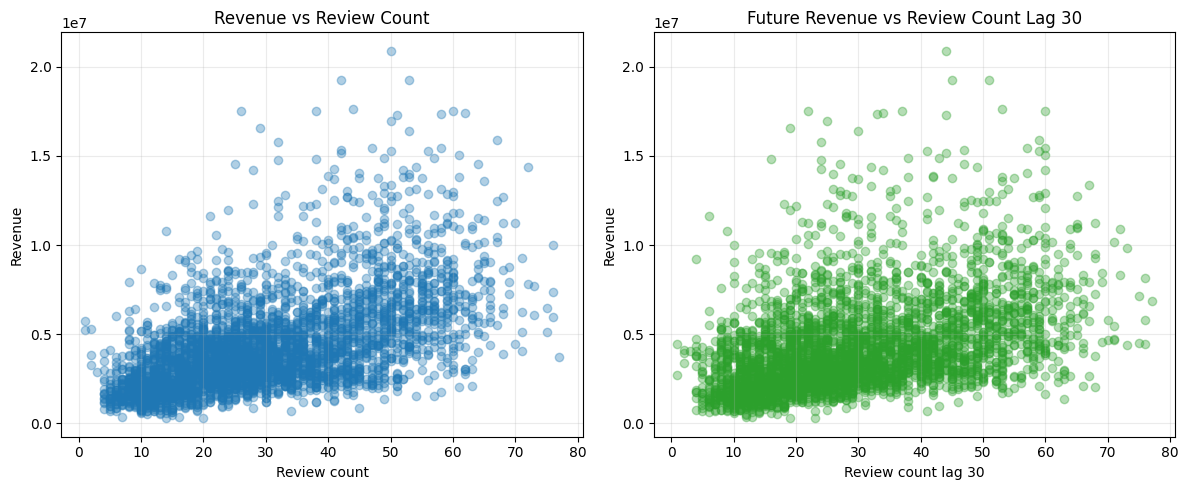

In [10]:
review_signal = pd.DataFrame()

if not reviews_clean.empty and not daily_revenue.empty and reviews_clean['review_date_std'].notna().any():
    daily_reviews = reviews_clean.groupby(reviews_clean['review_date_std'].dt.floor('D')).agg(
        review_count=('rating_std', 'size'),
        avg_rating=('rating_std', 'mean'),
        low_rating_ratio=('low_rating_flag', 'mean'),
    ).reset_index().rename(columns={'review_date_std': 'date'})
    daily_orders = sales_items.groupby(sales_items['order_date_std'].dt.floor('D')).agg(
        order_count=('order_id_std', 'nunique'),
        quantity_sold=('quantity_std', 'sum'),
        item_revenue=('item_revenue_std', 'sum'),
    ).reset_index().rename(columns={'order_date_std': 'date'}) if not sales_items.empty else pd.DataFrame()
    review_signal = daily_reviews.merge(daily_revenue, on='date', how='outer')
    if not daily_orders.empty:
        review_signal = review_signal.merge(daily_orders, on='date', how='left')
    review_signal = review_signal.sort_values('date')
    review_signal['review_count_lag_30'] = review_signal['review_count'].shift(30)
    display(review_signal.head(15))

    corr_table = pd.DataFrame([{
        'review_vs_Revenue': review_signal['review_count'].corr(review_signal['Revenue']),
        'review_vs_order_count': review_signal['review_count'].corr(review_signal['order_count']) if 'order_count' in review_signal.columns else np.nan,
        'review_vs_quantity_sold': review_signal['review_count'].corr(review_signal['quantity_sold']) if 'quantity_sold' in review_signal.columns else np.nan,
        'review_count_lag_vs_future_Revenue': review_signal['review_count_lag_30'].corr(review_signal['Revenue']),
    }])
    display(corr_table)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    tmp = review_signal.dropna(subset=['Revenue', 'review_count'])
    axes[0].scatter(tmp['review_count'], tmp['Revenue'], alpha=0.35, color='tab:blue')
    axes[0].set_title('Revenue vs Review Count')
    axes[0].set_xlabel('Review count')
    axes[0].set_ylabel('Revenue')
    tmp2 = review_signal.dropna(subset=['Revenue', 'review_count_lag_30'])
    axes[1].scatter(tmp2['review_count_lag_30'], tmp2['Revenue'], alpha=0.35, color='tab:green')
    axes[1].set_title('Future Revenue vs Review Count Lag 30')
    axes[1].set_xlabel('Review count lag 30')
    axes[1].set_ylabel('Revenue')
    plt.tight_layout()
    plt.show()
else:
    print('Review volume demand-signal analysis is limited because daily review and Revenue overlap is incomplete.')

## 11. Reviews, Returns, and Revenue Trend Over Time

Aggregate monthly review, rating, return, refund, and Revenue metrics and inspect the joint trend.

,month,Revenue,review_count,avg_rating,low_rating_ratio,return_count,returned_quantity,refund_amount
0,2012-07-01,"130,406,773.5100",220,4.0136,0.1091,107,294,"1,566,367.1600"
1,2012-08-01,"159,089,240.3100",1085,3.9558,0.1346,393,1044,"4,585,187.4100"
2,2012-09-01,"129,307,133.8200",1069,3.9429,0.1244,356,923,"4,141,199.9600"
3,2012-10-01,"110,185,694.4500",890,3.9281,0.1371,334,947,"4,401,616.9500"
4,2012-11-01,"98,186,295.2400",760,3.9671,0.1408,300,845,"3,774,908.0800"
5,2012-12-01,"114,322,610.6900",855,3.9228,0.1380,300,765,"2,652,778.4300"
6,2013-01-01,"91,308,677.0300",1250,3.9368,0.1320,408,1122,"3,679,987.1700"
7,2013-02-01,"109,783,137.9400",697,3.9168,0.1334,226,634,"2,356,109.1400"
8,2013-03-01,"151,834,657.2700",866,3.9238,0.1339,340,875,"3,340,464.5900"
9,2013-04-01,"198,926,932.0900",1363,3.9413,0.1387,538,1521,"6,080,560.2200"


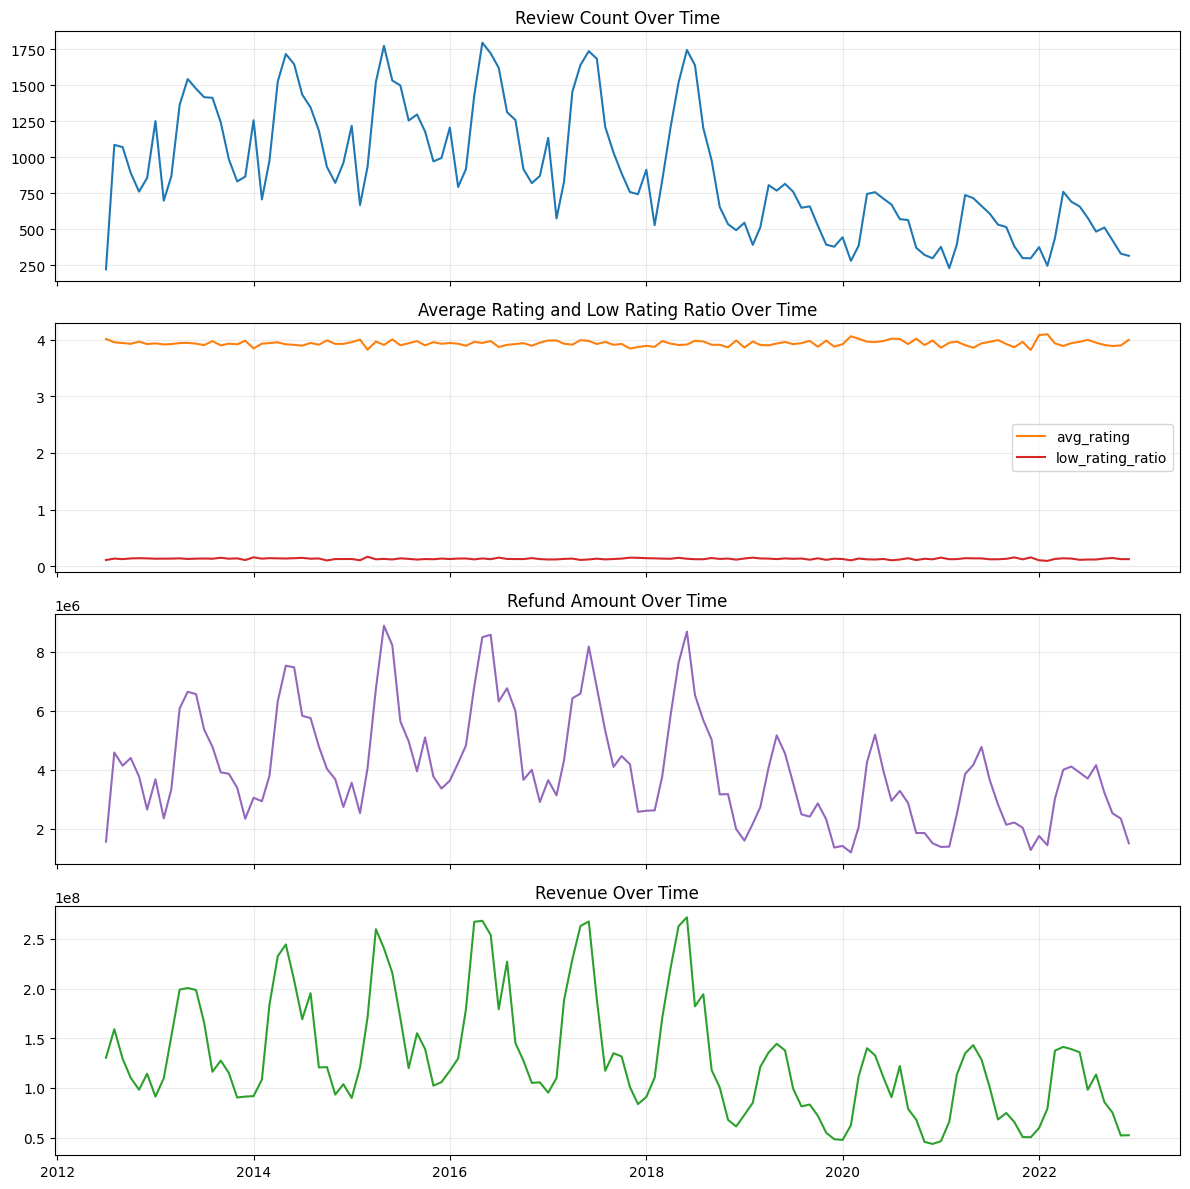

In [11]:
trend_monthly = pd.DataFrame()

if not daily_revenue.empty:
    rev_month = daily_revenue.assign(month=daily_revenue['date'].dt.to_period('M').dt.to_timestamp()).groupby('month').agg(Revenue=('Revenue', 'sum')).reset_index()
    if reviews_clean is not None and reviews_clean['review_date_std'].notna().any():
        revs_month = reviews_clean.assign(month=reviews_clean['review_date_std'].dt.to_period('M').dt.to_timestamp()).groupby('month').agg(
            review_count=('rating_std', 'size'),
            avg_rating=('rating_std', 'mean'),
            low_rating_ratio=('low_rating_flag', 'mean'),
        ).reset_index()
    else:
        revs_month = pd.DataFrame(columns=['month', 'review_count', 'avg_rating', 'low_rating_ratio'])
    if returns_clean is not None and returns_clean['return_date_std'].notna().any():
        rets_month = returns_clean.assign(month=returns_clean['return_date_std'].dt.to_period('M').dt.to_timestamp()).groupby('month').agg(
            return_count=('order_id_std', 'size'),
            returned_quantity=('return_quantity_std', 'sum'),
            refund_amount=('refund_amount_std', 'sum'),
        ).reset_index()
    else:
        rets_month = pd.DataFrame(columns=['month', 'return_count', 'returned_quantity', 'refund_amount'])

    trend_monthly = rev_month.merge(revs_month, on='month', how='left').merge(rets_month, on='month', how='left').sort_values('month')
    display(trend_monthly.head(15))

    fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
    axes[0].plot(trend_monthly['month'], trend_monthly['review_count'], color='tab:blue')
    axes[0].set_title('Review Count Over Time')
    axes[1].plot(trend_monthly['month'], trend_monthly['avg_rating'], color='tab:orange', label='avg_rating')
    axes[1].plot(trend_monthly['month'], trend_monthly['low_rating_ratio'], color='tab:red', label='low_rating_ratio')
    axes[1].legend()
    axes[1].set_title('Average Rating and Low Rating Ratio Over Time')
    axes[2].plot(trend_monthly['month'], trend_monthly['refund_amount'], color='tab:purple')
    axes[2].set_title('Refund Amount Over Time')
    axes[3].plot(trend_monthly['month'], trend_monthly['Revenue'], color='tab:green')
    axes[3].set_title('Revenue Over Time')
    plt.tight_layout()
    plt.show()

## 12. Category Risk Matrix

Combine Revenue, rating, review volume, and return pressure at category level to identify risk groups.

,category,review_count,avg_rating,low_rating_ratio,return_count,returned_quantity,refund_amount,Revenue,ordered_quantity,order_count,return_rate,refund_to_revenue_ratio,risk_group
3,Streetwear,62704,3.9394,0.1303,21799,59801,"406,708,249.1300","13,131,346,352.6200",1768826,389543,0.0338,0.0310,high_Revenue_high_rating_low_return
1,GenZ,5792,3.9228,0.1321,2126,5869,"11,145,648.1700","343,599,095.3600",166848,37054,0.0352,0.0324,low_Revenue_low_rating_high_return
2,Outdoor,41265,3.9339,0.1311,14720,40417,"78,717,514.8800","2,494,882,754.2000",1170000,200454,0.0345,0.0316,mixed
0,Casual,3790,3.9232,0.1372,1294,3499,"14,027,094.3700","460,648,383.3500",107469,23600,0.0326,0.0305,mixed


,Revenue,avg_rating,low_rating_ratio,review_count,return_rate,refund_to_revenue_ratio
Revenue,1.0000,0.8706,-0.5839,0.8855,-0.0863,-0.2921
avg_rating,0.8706,1.0000,-0.7182,0.9983,0.0606,-0.2139
low_rating_ratio,-0.5839,-0.7182,1.0000,-0.7471,-0.7285,-0.5226
review_count,0.8855,0.9983,-0.7471,1.0000,0.0966,-0.1754
return_rate,-0.0863,0.0606,-0.7285,0.0966,1.0000,0.9600
refund_to_revenue_ratio,-0.2921,-0.2139,-0.5226,-0.1754,0.9600,1.0000


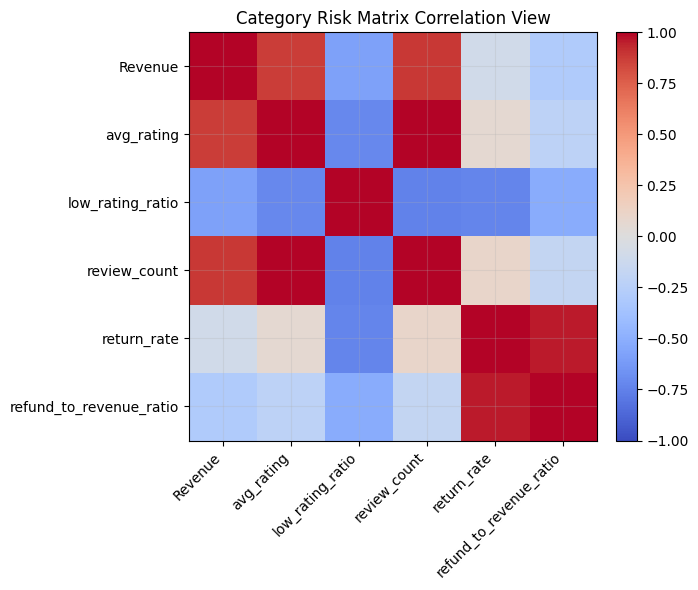

In [12]:
if not category_risk.empty:
    risk = category_risk.copy()
    risk['risk_group'] = np.select(
        [
            (risk['Revenue'] >= risk['Revenue'].median()) & (risk['avg_rating'] < risk['avg_rating'].median()) & (risk['return_rate'] >= risk['return_rate'].median()),
            (risk['Revenue'] >= risk['Revenue'].median()) & (risk['avg_rating'] >= risk['avg_rating'].median()) & (risk['return_rate'] < risk['return_rate'].median()),
            (risk['Revenue'] < risk['Revenue'].median()) & (risk['avg_rating'] < risk['avg_rating'].median()) & (risk['return_rate'] >= risk['return_rate'].median()),
            (risk['review_count'] >= risk['review_count'].median()) & (risk['Revenue'] < risk['Revenue'].median()),
        ],
        ['high_Revenue_low_rating_high_return', 'high_Revenue_high_rating_low_return', 'low_Revenue_low_rating_high_return', 'high_review_volume_weaker_Revenue'],
        default='mixed'
    )
    display(risk.sort_values(['risk_group', 'Revenue'], ascending=[True, False]))

    mat = risk[['Revenue', 'avg_rating', 'low_rating_ratio', 'review_count', 'return_rate', 'refund_to_revenue_ratio']].corr()
    display(mat)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(mat.values, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)
    ax.set_title('Category Risk Matrix Correlation View')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

## 13. Business Recommendation Insights

Translate the observed review, return, and Revenue patterns into practical recommendations.

In [13]:
if not category_risk.empty:
    print('Categories with low rating and high return pressure')
    display(category_risk.sort_values(['return_rate', 'avg_rating'], ascending=[False, True]).head(10))

if not product_risk.empty:
    print('Products with both low rating and high return pressure')
    display(product_risk[(product_risk['review_count'] >= max(5, int(product_risk['review_count'].median() or 5)))].sort_values(['low_rating_ratio', 'return_rate'], ascending=False).head(15))

if not trend_monthly.empty:
    deterioration = trend_monthly.copy()
    deterioration['avg_rating_change'] = deterioration['avg_rating'].diff()
    deterioration['Revenue_change'] = deterioration['Revenue'].diff()
    print('Months where ratings deteriorate and Revenue declines')
    display(deterioration[(deterioration['avg_rating_change'] < 0) & (deterioration['Revenue_change'] < 0)][['month', 'avg_rating_change', 'Revenue_change']].head(12))

Categories with low rating and high return pressure


,category,review_count,avg_rating,low_rating_ratio,return_count,returned_quantity,refund_amount,Revenue,ordered_quantity,order_count,return_rate,refund_to_revenue_ratio
1,GenZ,5792,3.9228,0.1321,2126,5869,"11,145,648.1700","343,599,095.3600",166848,37054,0.0352,0.0324
2,Outdoor,41265,3.9339,0.1311,14720,40417,"78,717,514.8800","2,494,882,754.2000",1170000,200454,0.0345,0.0316
3,Streetwear,62704,3.9394,0.1303,21799,59801,"406,708,249.1300","13,131,346,352.6200",1768826,389543,0.0338,0.0310
0,Casual,3790,3.9232,0.1372,1294,3499,"14,027,094.3700","460,648,383.3500",107469,23600,0.0326,0.0305


Products with both low rating and high return pressure


,product_id_std,review_count,avg_rating,low_rating_ratio,category,ordered_quantity,gross_revenue,order_count,return_count,returned_quantity,refund_amount,return_rate,refund_to_revenue_ratio
1317,2202,31,3.3548,0.3548,Casual,974,"3,570,102.2400",208,12.0000,29.0000,"96,077.6400",0.0298,0.0269
1235,2069,22,3.3182,0.3182,Streetwear,518,"3,088,275.5700",120,3.0000,8.0000,"43,583.9600",0.0154,0.0141
460,739,26,3.4615,0.3077,Outdoor,452,"916,032.5600",105,9.0000,21.0000,"41,599.6000",0.0465,0.0454
1222,2050,33,3.6364,0.3030,Streetwear,712,"4,028,878.1300",153,12.0000,35.0000,"177,022.8700",0.0492,0.0439
223,423,27,3.7778,0.2963,Streetwear,653,"7,270,471.3500",149,9.0000,21.0000,"195,473.4100",0.0322,0.0269
1125,1875,41,3.4146,0.2927,Streetwear,1608,"21,049,804.6400",356,20.0000,64.0000,"786,413.6400",0.0398,0.0374
688,1141,32,3.4062,0.2812,Streetwear,706,"6,665,750.9700",160,9.0000,17.0000,"158,760.7000",0.0241,0.0238
1117,1863,25,3.4400,0.2800,Streetwear,782,"7,303,053.4400",164,7.0000,26.0000,"231,744.2900",0.0332,0.0317
573,973,22,3.4545,0.2727,Streetwear,628,"4,386,973.4800",145,7.0000,11.0000,"71,384.0500",0.0175,0.0163
1107,1851,26,3.5385,0.2692,GenZ,788,"2,940,611.5300",186,9.0000,24.0000,"79,940.1800",0.0305,0.0272


Months where ratings deteriorate and Revenue declines


,month,avg_rating_change,Revenue_change
2,2012-09-01,-0.0128,"-29,782,106.4900"
3,2012-10-01,-0.0148,"-19,121,439.3700"
11,2013-06-01,-0.0147,"-1,982,480.9400"
12,2013-07-01,-0.0262,"-32,772,274.5500"
16,2013-11-01,-0.0116,"-24,718,524.9200"
23,2014-06-01,-0.0096,"-36,175,756.1000"
24,2014-07-01,-0.0146,"-38,975,838.5500"
26,2014-09-01,-0.0314,"-74,644,280.6400"
28,2014-11-01,-0.0623,"-27,689,201.0900"
34,2015-05-01,-0.0604,"-19,309,738.6500"


## 14. Leakage-Safe Review/Return Feature Preview

Create lagged historical review, rating, and return features only. Return/refund features are more appropriate for net-Revenue forecasting than gross-Revenue forecasting.

In [14]:
feature_preview = pd.DataFrame()

if not trend_monthly.empty:
    feat = trend_monthly.copy().sort_values('month')
    feat['avg_rating_lag'] = feat['avg_rating'].shift(1)
    feat['review_count_lag'] = feat['review_count'].shift(1)
    feat['low_rating_ratio_lag'] = feat['low_rating_ratio'].shift(1)
    feat['return_rate'] = np.where(feat['review_count'] > 0, feat['returned_quantity'] / feat['review_count'], np.nan)
    feat['return_rate_lag'] = feat['return_rate'].shift(1)
    feat['refund_amount_lag'] = feat['refund_amount'].shift(1)
    feat['avg_rating_roll_mean_3m'] = feat['avg_rating'].shift(1).rolling(3, min_periods=1).mean()
    feat['review_count_roll_sum_3m'] = feat['review_count'].shift(1).rolling(3, min_periods=1).sum()
    feat['low_rating_ratio_roll_mean_3m'] = feat['low_rating_ratio'].shift(1).rolling(3, min_periods=1).mean()
    feat['return_rate_roll_mean_3m'] = feat['return_rate'].shift(1).rolling(3, min_periods=1).mean()
    feat['category_low_rating_pressure_lag'] = category_risk['low_rating_ratio'].mean() if not category_risk.empty else np.nan
    feat['category_return_pressure_lag'] = category_risk['return_rate'].mean() if not category_risk.empty else np.nan
    display(feat.head(20))
    feature_preview = feat.head(20)

print('All features shown above are lagged historical aggregates only.')
print('Future reviews, ratings, returns, and refunds must not be used directly unless they are genuinely known before prediction.')

,month,Revenue,review_count,avg_rating,low_rating_ratio,return_count,returned_quantity,refund_amount,avg_rating_lag,review_count_lag,low_rating_ratio_lag,return_rate,return_rate_lag,refund_amount_lag,avg_rating_roll_mean_3m,review_count_roll_sum_3m,low_rating_ratio_roll_mean_3m,return_rate_roll_mean_3m,category_low_rating_pressure_lag,category_return_pressure_lag
0,2012-07-01,"130,406,773.5100",220,4.0136,0.1091,107,294,"1,566,367.1600",NaN,NaN,NaN,1.3364,NaN,NaN,NaN,NaN,NaN,NaN,0.1327,0.0340
1,2012-08-01,"159,089,240.3100",1085,3.9558,0.1346,393,1044,"4,585,187.4100",4.0136,220.0000,0.1091,0.9622,1.3364,"1,566,367.1600",4.0136,220.0000,0.1091,1.3364,0.1327,0.0340
2,2012-09-01,"129,307,133.8200",1069,3.9429,0.1244,356,923,"4,141,199.9600",3.9558,"1,085.0000",0.1346,0.8634,0.9622,"4,585,187.4100",3.9847,"1,305.0000",0.1218,1.1493,0.1327,0.0340
3,2012-10-01,"110,185,694.4500",890,3.9281,0.1371,334,947,"4,401,616.9500",3.9429,"1,069.0000",0.1244,1.0640,0.8634,"4,141,199.9600",3.9708,"2,374.0000",0.1227,1.0540,0.1327,0.0340
4,2012-11-01,"98,186,295.2400",760,3.9671,0.1408,300,845,"3,774,908.0800",3.9281,890.0000,0.1371,1.1118,1.0640,"4,401,616.9500",3.9423,"3,044.0000",0.1320,0.9632,0.1327,0.0340
5,2012-12-01,"114,322,610.6900",855,3.9228,0.1380,300,765,"2,652,778.4300",3.9671,760.0000,0.1408,0.8947,1.1118,"3,774,908.0800",3.9460,"2,719.0000",0.1341,1.0131,0.1327,0.0340
6,2013-01-01,"91,308,677.0300",1250,3.9368,0.1320,408,1122,"3,679,987.1700",3.9228,855.0000,0.1380,0.8976,0.8947,"2,652,778.4300",3.9393,"2,505.0000",0.1386,1.0235,0.1327,0.0340
7,2013-02-01,"109,783,137.9400",697,3.9168,0.1334,226,634,"2,356,109.1400",3.9368,"1,250.0000",0.1320,0.9096,0.8976,"3,679,987.1700",3.9422,"2,865.0000",0.1369,0.9681,0.1327,0.0340
8,2013-03-01,"151,834,657.2700",866,3.9238,0.1339,340,875,"3,340,464.5900",3.9168,697.0000,0.1334,1.0104,0.9096,"2,356,109.1400",3.9255,"2,802.0000",0.1345,0.9006,0.1327,0.0340
9,2013-04-01,"198,926,932.0900",1363,3.9413,0.1387,538,1521,"6,080,560.2200",3.9238,866.0000,0.1339,1.1159,1.0104,"3,340,464.5900",3.9258,"2,813.0000",0.1331,0.9392,0.1327,0.0340


All features shown above are lagged historical aggregates only.
Future reviews, ratings, returns, and refunds must not be used directly unless they are genuinely known before prediction.


## 15. Key Observations and Warnings

Summarize whether low ratings align with return pressure, whether rating deterioration is followed by Revenue decline, and which review or return signals look most useful.

In [15]:
summary_lines = ['KEY OBSERVATIONS AND WARNINGS']

if not category_risk.empty:
    corr_rating_return = category_risk['avg_rating'].corr(category_risk['return_rate'])
    summary_lines.append(f'- Low ratings appear associated with higher return rate at category level under correlation {corr_rating_return:.4f}.')
    top_cat = category_risk.sort_values(['return_rate', 'avg_rating'], ascending=[False, True]).head(3)
    summary_lines.append('- Categories with low rating and high return pressure: ' + ', '.join(f"{r.category}" for r in top_cat.itertuples()) + '.')

if not product_risk.empty:
    top_prod = product_risk[(product_risk['review_count'] >= max(5, int(product_risk['review_count'].median() or 5)))].sort_values(['low_rating_ratio', 'return_rate'], ascending=False).head(5)
    if not top_prod.empty:
        summary_lines.append('- Products with low rating and high return pressure: ' + ', '.join(f"{r.product_id_std}" for r in top_prod.itertuples()) + '.')

if not category_future.empty:
    lag_corr = category_future['avg_rating_lag_1m'].corr(category_future['future_Revenue_1m'])
    summary_lines.append(f'- Low category rating is followed by future Revenue change with lag correlation {lag_corr:.4f}.')

if not review_signal.empty:
    rev_corr = review_signal['review_count'].corr(review_signal['Revenue'])
    ord_corr = review_signal['review_count'].corr(review_signal['order_count']) if 'order_count' in review_signal.columns else np.nan
    qty_corr = review_signal['review_count'].corr(review_signal['quantity_sold']) if 'quantity_sold' in review_signal.columns else np.nan
    summary_lines.append(f'- Review volume appears to be a {"useful" if abs(rev_corr) > 0.2 else "weak or noisy"} demand signal (Revenue corr {rev_corr:.4f}).')
    summary_lines.append(f'- Review count is related to Revenue/order_count/quantity_sold as {rev_corr:.4f} / {ord_corr:.4f} / {qty_corr:.4f}.')

if not category_risk.empty:
    high_risk_groups = category_risk.copy()
    high_risk_groups['risk_group'] = np.select(
        [
            (high_risk_groups['Revenue'] >= high_risk_groups['Revenue'].median()) & (high_risk_groups['avg_rating'] < high_risk_groups['avg_rating'].median()) & (high_risk_groups['return_rate'] >= high_risk_groups['return_rate'].median()),
            (high_risk_groups['Revenue'] >= high_risk_groups['Revenue'].median()) & (high_risk_groups['avg_rating'] >= high_risk_groups['avg_rating'].median()) & (high_risk_groups['return_rate'] < high_risk_groups['return_rate'].median()),
        ],
        ['high_Revenue_low_rating_high_return', 'high_Revenue_high_rating_low_return'],
        default='other'
    )
    summary_lines.append('- Category risk groups: ' + ', '.join(f"{r.category}:{r.risk_group}" for r in high_risk_groups.head(6).itertuples()) + '.')

summary_lines.append('- Business recommendations: improve quality and product descriptions in categories with both lower ratings and higher returns; monitor low-rating ratio as an early warning indicator; use review volume as a demand signal only where correlation is stable; prioritize categories/products with high refund-to-revenue ratio for quality and CX review.')

quality_notes = []
if reviews_clean is not None:
    invalid = int((reviews_clean['rating_std'].notna() & ~reviews_clean['rating_std'].between(1, 5)).sum())
    if invalid:
        quality_notes.append(f'{invalid} reviews have invalid ratings')
    unmatched = int((review_enriched['product_merge'] == 'left_only').sum()) if not review_enriched.empty and 'product_merge' in review_enriched.columns else 0
    if unmatched:
        quality_notes.append(f'{unmatched} reviews have no product match')
if returns_clean is not None:
    unmatched_ret = int((return_enriched['product_merge'] == 'left_only').sum()) if not return_enriched.empty and 'product_merge' in return_enriched.columns else 0
    if unmatched_ret:
        quality_notes.append(f'{unmatched_ret} returns have no product match')
if not sales_items.empty:
    sparse = int((category_month.groupby('category')['month'].nunique() < 3).sum()) if not category_month.empty else 0
    if sparse:
        quality_notes.append(f'{sparse} categories have sparse month coverage')

if quality_notes:
    summary_lines.append('- Review/return/Revenue data quality warnings: ' + '; '.join(quality_notes))
else:
    summary_lines.append('- Review/return/Revenue data quality warnings: none beyond the checks reported in notebook tables.')

summary_lines.append('- Recommended leakage-safe review/rating/return features: avg_rating_lag, review_count_lag, low_rating_ratio_lag, return_rate_lag, refund_amount_lag, avg_rating_roll_mean_3m, review_count_roll_sum_3m, low_rating_ratio_roll_mean_3m, return_rate_roll_mean_3m, category_low_rating_pressure_lag, and category_return_pressure_lag.')
summary_lines.append('- Future reviews, ratings, returns, and refund values must not be used directly unless they are genuinely known before prediction.')
summary_lines.append('- Causal caution: these are observational associations and can reflect seasonality, product mix, promotion, traffic, price, and inventory availability.')

print('\n'.join(summary_lines))

KEY OBSERVATIONS AND WARNINGS
- Low ratings appear associated with higher return rate at category level under correlation 0.0606.
- Categories with low rating and high return pressure: GenZ, Outdoor, Streetwear.
- Products with low rating and high return pressure: 2202, 2069, 739, 2050, 423.
- Low category rating is followed by future Revenue change with lag correlation 0.0425.
- Review volume appears to be a useful demand signal (Revenue corr 0.5611).
- Review count is related to Revenue/order_count/quantity_sold as 0.5611 / 0.5876 / 0.5751.
- Category risk groups: Casual:other, GenZ:other, Outdoor:other, Streetwear:high_Revenue_high_rating_low_return.
- Business recommendations: improve quality and product descriptions in categories with both lower ratings and higher returns; monitor low-rating ratio as an early warning indicator; use review volume as a demand signal only where correlation is stable; prioritize categories/products with high refund-to-revenue ratio for quality and CX 